# Rank 0 Pipeline Schedule — Actual Measurements

This notebook shows **only what we actually measured** from the fe127_d16_rank0 trace.

- **Rank 0** = first GPU on node 1, **pipeline stage 0** (38 transformer layers)
- **Rank 8** = first GPU on node 2, **pipeline stage 1** (40 transformer layers + loss head) — **not in this trace**
- 16 microbatches, indexed from 1

**Verified**: 608 forward blocks ÷ 16 microbatches = 38 layers per microbatch on rank 0

**Key limitation**: We cannot see rank 8. The gaps in rank 0's timeline are when it's waiting for rank 8.

In [6]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np

TRACE_PATH = '/Users/jackrao/perf_profiles/lps-1062/pp2cp8ep8/fe127_d16_rank0.pt.trace.json'

In [7]:
# Load trace
print("Loading trace...")
with open(TRACE_PATH) as f:
    trace = json.load(f)

# Find trace start time — ts is in microseconds, convert to ns
trace_start_ns = None
for e in trace['traceEvents']:
    if e.get('name') == 'PyTorch Profiler (0)' and e.get('ph') == 'X':
        trace_start_ns = e['ts'] * 1000  # microseconds to nanoseconds
        break

print(f"Loaded {len(trace['traceEvents'])} events")
print(f"Trace start: {trace_start_ns} ns")

Loading trace...
Loaded 10490461 events
Trace start: 3670400354372054.0 ns


In [8]:
# Extract forward and backward events from rank 0
forward_events = []
backward_events = []

for e in trace['traceEvents']:
    if e.get('ph') != 'X':
        continue
    name = e.get('name', '')
    ts = e.get('ts', 0)  # microseconds
    dur = e.get('dur', 0)  # microseconds
    
    # Convert to seconds relative to trace start
    start_s = (ts * 1000 - trace_start_ns) / 1e9
    dur_s = dur / 1e6
    
    if name == 'CheckpointFunction' and dur_s > 0.01:
        forward_events.append({'start': start_s, 'dur': dur_s, 'end': start_s + dur_s})
    elif name == 'CheckpointFunctionBackward' and dur_s > 0.01:
        backward_events.append({'start': start_s, 'dur': dur_s, 'end': start_s + dur_s})

forward_events.sort(key=lambda x: x['start'])
backward_events.sort(key=lambda x: x['start'])

print(f"Forward blocks: {len(forward_events)} (38 layers × 16 microbatches)")
print(f"Backward blocks: {len(backward_events)}")
print(f"Forward time range: {forward_events[0]['start']:.2f}s - {forward_events[-1]['end']:.2f}s")
print(f"Backward time range: {backward_events[0]['start']:.2f}s - {backward_events[-1]['end']:.2f}s")

Forward blocks: 608 (38 layers × 16 microbatches)
Backward blocks: 608
Forward time range: 1.34s - 118.19s
Backward time range: 10.99s - 131.32s


In [9]:
# Group into microbatches: 38 layers per microbatch on rank 0
LAYERS_PER_MB = 38
NUM_MICROBATCHES = 16

def group_into_microbatches(events, layers_per_mb):
    microbatches = []
    for i in range(0, len(events), layers_per_mb):
        chunk = events[i:i+layers_per_mb]
        if chunk:
            microbatches.append({
                'start': min(e['start'] for e in chunk),
                'end': max(e['end'] for e in chunk),
                'dur': max(e['end'] for e in chunk) - min(e['start'] for e in chunk)
            })
    return microbatches

fwd_mbs = group_into_microbatches(forward_events, LAYERS_PER_MB)
bwd_mbs = group_into_microbatches(backward_events, LAYERS_PER_MB)

print("Microbatch timing (rank 0, actual measurements):")
print("=" * 75)
print(f"{'MB':>3} {'FWD Start':>10} {'FWD End':>10} {'FWD Dur':>9} {'BWD Start':>10} {'BWD End':>10} {'BWD Dur':>9}")
print("-" * 75)
for i in range(16):
    f = fwd_mbs[i]
    b = bwd_mbs[i]
    print(f"{i+1:3d} {f['start']:10.2f} {f['end']:10.2f} {f['dur']:9.2f} {b['start']:10.2f} {b['end']:10.2f} {b['dur']:9.2f}")

print("=" * 75)
print(f"\nKey observations:")
print(f"  MB 1-2 forward: back-to-back ({fwd_mbs[0]['start']:.2f}s - {fwd_mbs[1]['end']:.2f}s, no gap)")
print(f"  Pipeline fill: {bwd_mbs[0]['start'] - fwd_mbs[0]['end']:.2f}s gap between F1 end and B1 start")
print(f"  Total duration: {bwd_mbs[-1]['end']:.1f}s")

Microbatch timing (rank 0, actual measurements):
 MB  FWD Start    FWD End   FWD Dur  BWD Start    BWD End   BWD Dur
---------------------------------------------------------------------------
  1       1.34       3.65      2.32      10.99      15.73      4.73
  2       3.67       5.92      2.25      18.22      23.17      4.95
  3      15.73      18.13      2.40      26.02      30.72      4.70
  4      23.17      25.99      2.82      33.26      38.63      5.37
  5      30.72      32.96      2.24      41.49      46.28      4.79
  6      38.63      41.38      2.75      48.95      54.73      5.78
  7      46.28      48.93      2.65      57.76      62.49      4.73
  8      54.73      57.73      3.00      64.95      70.47      5.52
  9      62.49      64.72      2.23      72.69      77.39      4.70
 10      70.47      72.67      2.20      79.92      85.36      5.45
 11      77.39      79.49      2.10      87.58      92.41      4.83
 12      85.36      87.55      2.19      94.81     100.00  

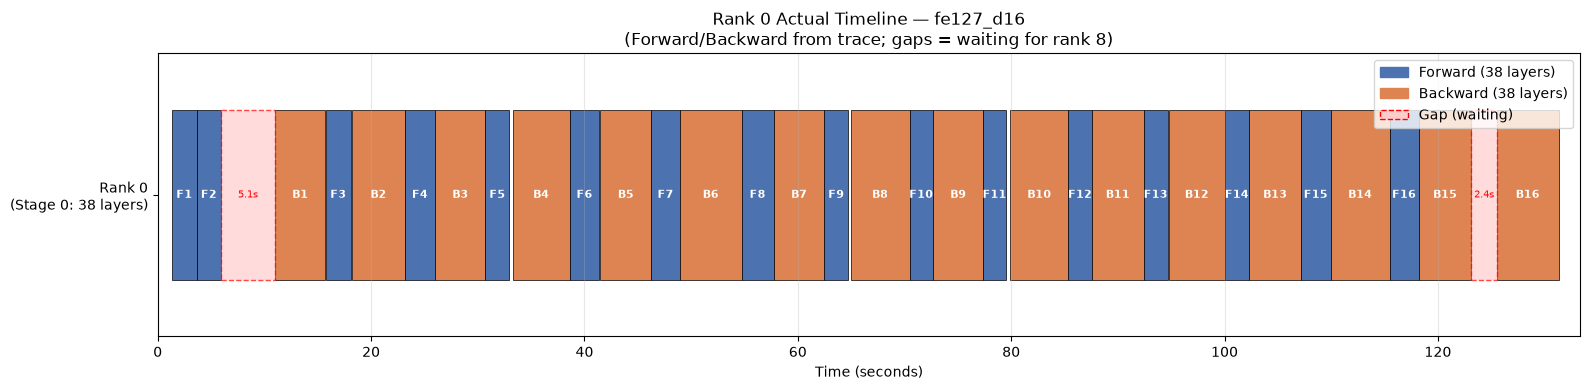

In [10]:
# Create visualization: Rank 0 only, actual measurements
fig, ax = plt.subplots(figsize=(16, 4))

FWD_COLOR = '#4C72B0'  # Blue
BWD_COLOR = '#DD8452'  # Orange
GAP_COLOR = '#FFCCCC'  # Light red for gaps

bar_height = 0.6
y_pos = 0

# Combine and sort all events
all_events = []
for i, mb in enumerate(fwd_mbs):
    all_events.append({'start': mb['start'], 'end': mb['end'], 'type': 'F', 'mb': i+1, 'dur': mb['dur']})
for i, mb in enumerate(bwd_mbs):
    all_events.append({'start': mb['start'], 'end': mb['end'], 'type': 'B', 'mb': i+1, 'dur': mb['dur']})
all_events.sort(key=lambda x: x['start'])

# Plot events
for event in all_events:
    color = FWD_COLOR if event['type'] == 'F' else BWD_COLOR
    rect = Rectangle(
        (event['start'], y_pos - bar_height/2),
        event['dur'],
        bar_height,
        facecolor=color,
        edgecolor='black',
        linewidth=0.5
    )
    ax.add_patch(rect)
    ax.text(
        (event['start'] + event['end']) / 2,
        y_pos,
        f"{event['type']}{event['mb']}",
        ha='center',
        va='center',
        fontsize=8,
        color='white',
        fontweight='bold'
    )

# Highlight significant gaps
for i in range(len(all_events) - 1):
    curr_end = all_events[i]['end']
    next_start = all_events[i+1]['start']
    gap = next_start - curr_end
    if gap > 0.5:
        rect = Rectangle(
            (curr_end, y_pos - bar_height/2),
            gap,
            bar_height,
            facecolor=GAP_COLOR,
            edgecolor='red',
            linewidth=1,
            alpha=0.7,
            linestyle='--'
        )
        ax.add_patch(rect)
        ax.text(
            (curr_end + next_start) / 2,
            y_pos,
            f"{gap:.1f}s",
            ha='center',
            va='center',
            fontsize=7,
            color='red'
        )

# Formatting
ax.set_yticks([y_pos])
ax.set_yticklabels(['Rank 0\n(Stage 0: 38 layers)'])
ax.set_xlabel('Time (seconds)')
ax.set_title('Rank 0 Actual Timeline — fe127_d16\n(Forward/Backward from trace; gaps = waiting for rank 8)')
ax.set_xlim(0, max(e['end'] for e in all_events) + 2)
ax.set_ylim(-0.5, 0.5)
ax.grid(axis='x', alpha=0.3)

# Legend
fwd_patch = mpatches.Patch(color=FWD_COLOR, label='Forward (38 layers)')
bwd_patch = mpatches.Patch(color=BWD_COLOR, label='Backward (38 layers)')
gap_patch = mpatches.Patch(facecolor=GAP_COLOR, edgecolor='red', linestyle='--', label='Gap (waiting)')
ax.legend(handles=[fwd_patch, bwd_patch, gap_patch], loc='upper right')

plt.tight_layout()
plt.show()

## Verification

**Data source**: `fe127_d16_rank0.pt.trace.json` — actual kineto trace from rank 0

**Verified measurements:**
- 608 `CheckpointFunction` blocks (forward) = 38 layers × 16 microbatches
- 608 `CheckpointFunctionBackward` blocks (backward) = 38 layers × 16 microbatches
- Thread 124117 (python) dispatches forward work
- Thread 122219 (pt_autograd_0) dispatches backward work

**Microbatch timing table (actual data):**

| MB | FWD Start | FWD End | FWD Dur | BWD Start | BWD End | BWD Dur |
|----|-----------|---------|---------|-----------|---------|---------|
| 1 | 1.34s | 3.65s | 2.32s | 10.99s | 15.73s | 4.73s |
| 2 | 3.67s | 5.92s | 2.25s | 18.22s | 23.17s | 4.95s |
| 3 | 15.73s | 18.13s | 2.40s | 26.02s | 30.72s | 4.70s |
| 4 | 23.17s | 25.99s | 2.82s | 33.26s | 38.63s | 5.37s |
| 5 | 30.72s | 32.96s | 2.24s | 41.49s | 46.28s | 4.79s |
| 6 | 38.63s | 41.38s | 2.75s | 48.95s | 54.73s | 5.78s |
| 7 | 46.28s | 48.93s | 2.65s | 57.76s | 62.49s | 4.73s |
| 8 | 54.73s | 57.73s | 3.00s | 64.95s | 70.47s | 5.52s |
| 9 | 62.49s | 64.72s | 2.23s | 72.69s | 77.39s | 4.70s |
| 10 | 70.47s | 72.67s | 2.20s | 79.92s | 85.36s | 5.45s |
| 11 | 77.39s | 79.49s | 2.10s | 87.58s | 92.41s | 4.83s |
| 12 | 85.37s | 87.55s | 2.19s | 94.81s | 100.00s | 5.18s |
| 13 | 92.41s | 94.68s | 2.27s | 102.34s | 107.15s | 4.82s |
| 14 | 100.00s | 102.31s | 2.32s | 109.96s | 115.47s | 5.51s |
| 15 | 107.15s | 109.95s | 2.80s | 118.21s | 123.13s | 4.92s |
| 16 | 115.47s | 118.19s | 2.72s | 125.52s | 131.32s | 5.79s |

**Key pattern:**
- MB 1-2 forward: back-to-back (1.34s - 5.92s, no gap) — 1F1B warmup
- 7.34s gap between F1 end and B1 start — pipeline fill time
- Steady state: F/B alternate with ~5s gaps (waiting for rank 8)

**What we don't see:**
- Rank 8 (pipeline stage 1: 40 layers + loss head)
- Network transfer between nodes
- Actual GPU kernel execution (only CPU dispatch side)